<a href="https://colab.research.google.com/github/nibaskumar93n-debug/Morphoinformatics/blob/main/Key_gene_selection_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import subprocess
subprocess.run(["pip", "install", "-q",
                "xgboost", "shap", "scikit-learn",
                "pandas", "numpy", "matplotlib",
                "seaborn"], check=True)
print("✅ All packages installed!")

✅ All packages installed!


In [19]:
DESCRIP_FILE  = 'pred_metagenome_unstrat_descrip.tsv'
METADATA_FILE = 'metadata.tsv'

print('✅ Files ready:')
print(f'   descrip  → {DESCRIP_FILE}')
print(f'   metadata → {METADATA_FILE}')

✅ Files ready:
   descrip  → pred_metagenome_unstrat_descrip.tsv
   metadata → metadata.tsv


In [20]:
TARGET_COLUMN  = "Groups"
CLASS_POSITIVE = "DKD"
CLASS_NEGATIVE = "HC"

TOP_N        = 20
N_CV_FOLDS   = 5
RANDOM_STATE = 42

print("✅ Configuration set:")
print(f"  Descrip file  : {DESCRIP_FILE}")
print(f"  Metadata file : {METADATA_FILE}")
print(f"  Target column : '{TARGET_COLUMN}'  ({CLASS_POSITIVE} vs {CLASS_NEGATIVE})")
print(f"  Top N genes   : {TOP_N}")

✅ Configuration set:
  Descrip file  : pred_metagenome_unstrat_descrip.tsv
  Metadata file : metadata.tsv
  Target column : 'Groups'  (DKD vs HC)
  Top N genes   : 20


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier
import shap

print("✅ Libraries imported!")

✅ Libraries imported!


In [22]:
raw = pd.read_csv(DESCRIP_FILE, sep='\t', index_col=0, comment='#')

desc_col = next((c for c in raw.columns if 'desc' in c.lower()), None)

if desc_col:
    annot_raw  = raw[[desc_col]].copy()
    gene_table = raw.drop(columns=[desc_col])
else:
    annot_raw  = pd.DataFrame(index=raw.index)
    gene_table = raw.copy()

gene_table = gene_table.T
gene_table = gene_table.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Gene table : {gene_table.shape[0]} samples × {gene_table.shape[1]} KO genes")
print(f"  Sample IDs : {gene_table.index[:3].tolist()}")
print(f"  KO IDs     : {gene_table.columns[:3].tolist()}")

Gene table : 319 samples × 4398 KO genes
  Sample IDs : ['SRR22270903', 'SRR22270904', 'SRR22270905']
  KO IDs     : ['K00001', 'K00003', 'K00004']


In [24]:
def split_desc(val):
    val = str(val)
    if ';' in val:
        gene_part, def_part = val.split(';', 1)
        return gene_part.strip().split(',')[0].strip(), def_part.strip()
    return val.strip(), val.strip()

if desc_col:
    annot_raw[['gene_name', 'definition']] = annot_raw[desc_col].apply(
        lambda x: pd.Series(split_desc(x))
    )
    annot_df = annot_raw[['gene_name', 'definition']].copy()
    annot_df.index.name = 'KO'
else:
    annot_df = pd.DataFrame(index=gene_table.columns)
    annot_df['gene_name']  = 'Unknown'
    annot_df['definition'] = 'No annotation'

print(f"✅ {len(annot_df)} KO annotations parsed")
print(annot_df.head(5).to_string())

✅ 4398 KO annotations parsed
       gene_name                                                                                                          definition
KO                                                                                                                                  
K00001  E1.1.1.1                                                                                  alcohol dehydrogenase [EC:1.1.1.1]
K00003  E1.1.1.3                                                                               homoserine dehydrogenase [EC:1.1.1.3]
K00004       BDH  (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [EC:1.1.1.4 1.1.1.- 1.1.1.303]
K00005      gldA                                                                                 glycerol dehydrogenase [EC:1.1.1.6]
K00007      dalD                                                                          D-arabinitol 4-dehydrogenase [EC:1.1.1.11]


In [25]:
sep = '\t' if METADATA_FILE.endswith('.tsv') else ','
metadata = pd.read_csv(METADATA_FILE, sep=sep, index_col=0)
metadata.index = metadata.index.astype(str)
if str(metadata.index[0]).startswith('#'):
    metadata = metadata.iloc[1:]

gene_table.index = gene_table.index.astype(str)

common = gene_table.index.intersection(metadata.index)
print(f"Samples in gene table : {len(gene_table)}")
print(f"Samples in metadata   : {len(metadata)}")
print(f"Common samples        : {len(common)}")

if len(common) == 0:
    raise ValueError("❌ No common samples! Check sample ID formatting.")

gene_table = gene_table.loc[common]
metadata   = metadata.loc[common].dropna(subset=[TARGET_COLUMN])
gene_table = gene_table.loc[metadata.index]
print(f"Samples after dropping missing target: {len(gene_table)}")

# Normalise: relative abundance → log(CPM + 1)
gene_table = gene_table.div(gene_table.sum(axis=1), axis=0)
gene_table = np.log1p(gene_table * 1e6)

# Drop zero-variance genes
gene_table = gene_table.loc[:, gene_table.var() > 0]
print(f"Genes after zero-variance filter: {gene_table.shape[1]}")

X             = gene_table.values
feature_names = gene_table.columns.tolist()
le            = LabelEncoder()
y             = le.fit_transform(metadata[TARGET_COLUMN].astype(str).values)
classes       = le.classes_
n_classes     = len(classes)

print(f"\nTarget classes : {list(classes)}")
print(f"Class counts   : {dict(zip(classes, np.bincount(y)))}")

Samples in gene table : 319
Samples in metadata   : 319
Common samples        : 319
Samples after dropping missing target: 319
Genes after zero-variance filter: 4398

Target classes : ['DKD', 'HC']
Class counts   : {'DKD': np.int64(180), 'HC': np.int64(139)}


In [26]:
model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "mlogloss" if n_classes > 2 else "logloss",
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)

cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X, y, cv=cv,
                             scoring='roc_auc_ovr' if n_classes > 2 else 'roc_auc')

print(f"CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold: {[round(s, 4) for s in cv_scores]}")

model.fit(X, y)
print("✅ Final model trained")

CV AUC: 0.9884 ± 0.0032
Per-fold: [np.float64(0.9901), np.float64(0.9851), np.float64(0.9931), np.float64(0.9891), np.float64(0.9846)]
✅ Final model trained


In [27]:
importances   = model.feature_importances_
importance_df = pd.DataFrame({
    "KO"        : feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

importance_df['gene_name']  = importance_df['KO'].map(annot_df['gene_name']).fillna('Unknown')
importance_df['definition'] = importance_df['KO'].map(annot_df['definition']).fillna('No annotation')
importance_df['Label'] = importance_df.apply(
    lambda r: r['gene_name'] if r['gene_name'] not in ['', 'Unknown'] else r['KO'], axis=1
)

print("✅ Gene importance computed & annotations mapped")
print(f"\nTop 10 genes by XGBoost gain:")
print(importance_df[['KO','gene_name','Importance','definition']].head(10).to_string(index=False))

✅ Gene importance computed & annotations mapped

Top 10 genes by XGBoost gain:
    KO gene_name  Importance                                                              definition
K01181  E3.2.1.8    0.078409                                     endo-1,4-beta-xylanase [EC:3.2.1.8]
K03409      cheX    0.050639                                                 chemotaxis protein CheX
K01235      aguA    0.028762                                      alpha-glucuronidase [EC:3.2.1.139]
K06987    K06987    0.028682                                                 uncharacterized protein
K07080    K07080    0.026203                                                 uncharacterized protein
K01209      abfA    0.019225                               alpha-N-arabinofuranosidase [EC:3.2.1.55]
K00992      murU    0.015862 N-acetyl-alpha-D-muramate 1-phosphate uridylyltransferase [EC:2.7.7.99]
K03293    TC.AAT    0.014485                                      amino acid transporter, AAT family
K00034      

In [28]:
print("Computing SHAP values ...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "KO"       : feature_names,
    "Mean_SHAP": mean_shap
}).sort_values("Mean_SHAP", ascending=False).reset_index(drop=True)

label_map = importance_df.set_index("KO")["Label"]
shap_df["Label"]      = shap_df["KO"].map(label_map).fillna(shap_df["KO"])
shap_df["gene_name"]  = shap_df["KO"].map(annot_df["gene_name"]).fillna("Unknown")
shap_df["definition"] = shap_df["KO"].map(annot_df["definition"]).fillna("No annotation")

print("✅ SHAP values computed!")
print(f"\nTop 10 genes by SHAP:")
print(shap_df[["KO","gene_name","Mean_SHAP","definition"]].head(10).to_string(index=False))

Computing SHAP values ...
✅ SHAP values computed!

Top 10 genes by SHAP:
    KO gene_name  Mean_SHAP                                                              definition
K01181  E3.2.1.8   0.496669                                     endo-1,4-beta-xylanase [EC:3.2.1.8]
K00034       gdh   0.493372                                   glucose 1-dehydrogenase [EC:1.1.1.47]
K01739      metB   0.478073                              cystathionine gamma-synthase [EC:2.5.1.48]
K07080    K07080   0.448492                                                 uncharacterized protein
K03409      cheX   0.353858                                                 chemotaxis protein CheX
K09952      csn1   0.298929                        CRISPR-associated endonuclease Csn1 [EC:3.1.-.-]
K01533      copB   0.273108                                      Cu2+-exporting ATPase [EC:3.6.3.4]
K00992      murU   0.220530 N-acetyl-alpha-D-muramate 1-phosphate uridylyltransferase [EC:2.7.7.99]
K07029      dagK   0.214556

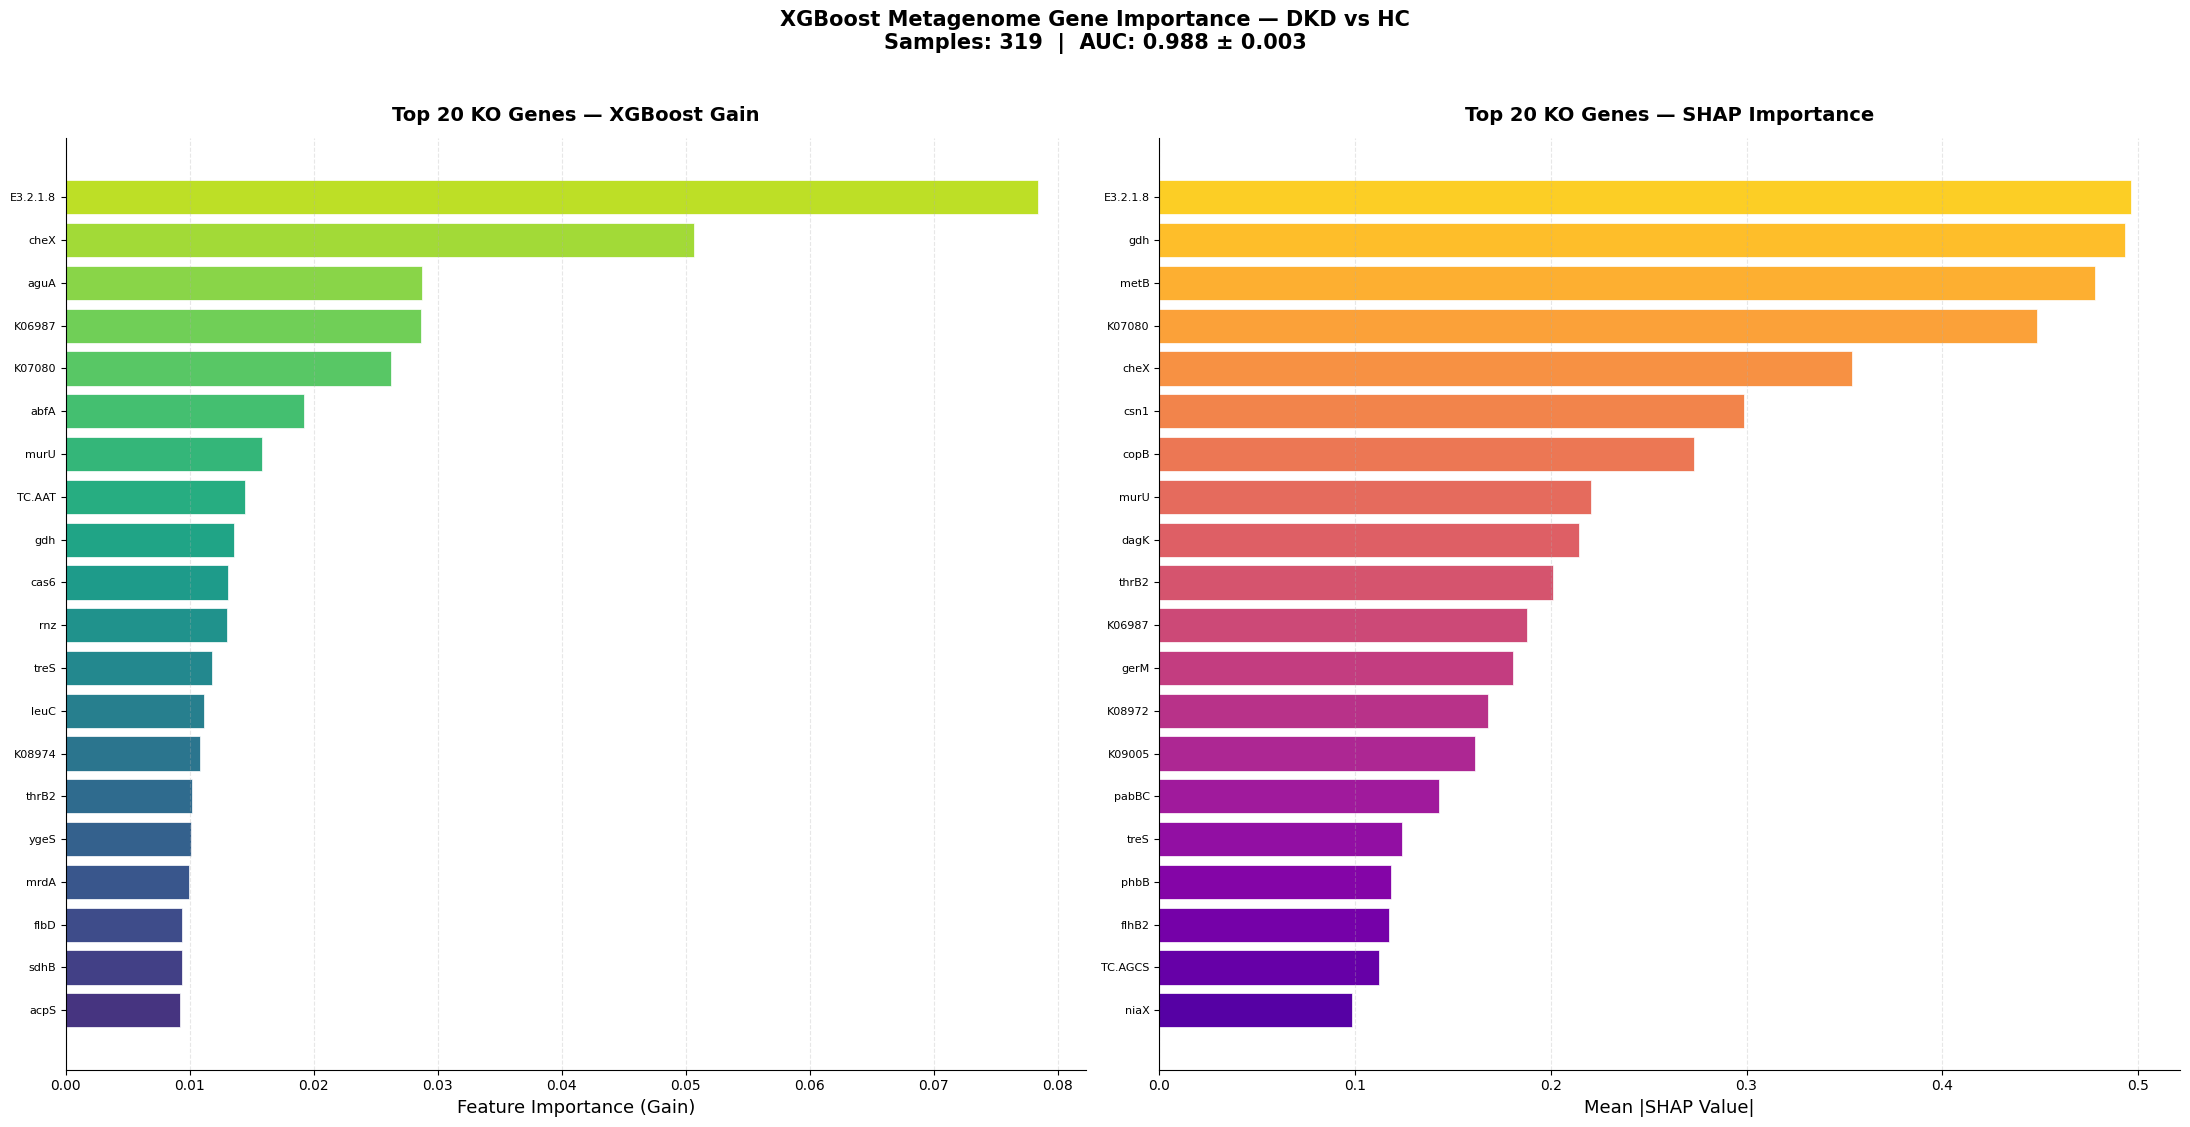

✅ Saved: importance_plots.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

top_imp = importance_df.head(TOP_N).sort_values("Importance")
cmap_a  = plt.cm.viridis(np.linspace(0.15, 0.9, len(top_imp)))
axes[0].barh(top_imp["Label"], top_imp["Importance"],
             color=cmap_a, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Feature Importance (Gain)", fontsize=13)
axes[0].set_title(f"Top {TOP_N} KO Genes — XGBoost Gain",
                  fontsize=14, fontweight="bold", pad=12)
axes[0].tick_params(axis="y", labelsize=8)
axes[0].grid(axis="x", alpha=0.3, linestyle="--")
axes[0].spines[["top","right"]].set_visible(False)

top_shap = shap_df.head(TOP_N).sort_values("Mean_SHAP")
cmap_b   = plt.cm.plasma(np.linspace(0.15, 0.9, len(top_shap)))
axes[1].barh(top_shap["Label"], top_shap["Mean_SHAP"],
             color=cmap_b, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Mean |SHAP Value|", fontsize=13)
axes[1].set_title(f"Top {TOP_N} KO Genes — SHAP Importance",
                  fontsize=14, fontweight="bold", pad=12)
axes[1].tick_params(axis="y", labelsize=8)
axes[1].grid(axis="x", alpha=0.3, linestyle="--")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle(
    f"XGBoost Metagenome Gene Importance — DKD vs HC\n"
    f"Samples: {len(X)}  |  AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("importance_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: importance_plots.png")

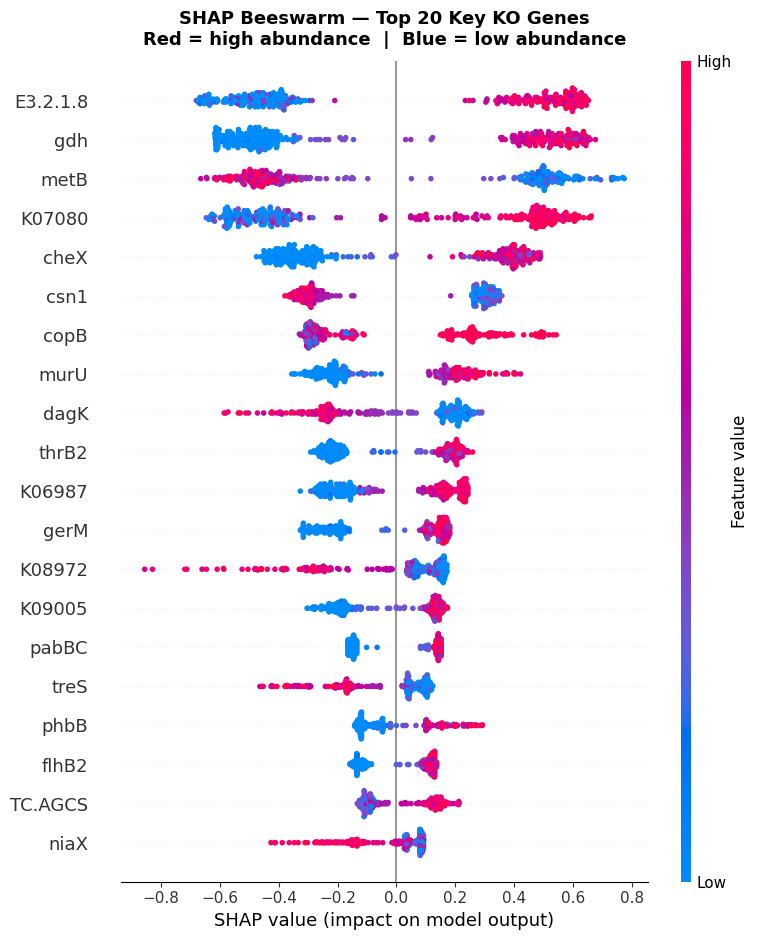

✅ Saved: shap_beeswarm.png


In [30]:
top_fids   = shap_df.head(TOP_N)["KO"].tolist()
top_idx    = [feature_names.index(f) for f in top_fids if f in feature_names]
top_labels = [shap_df.loc[shap_df["KO"] == feature_names[i], "Label"].values[0]
               for i in top_idx]

shap_vals_plot = shap_values[0] if isinstance(shap_values, list) else shap_values
base_val       = (explainer.expected_value[0]
                  if isinstance(explainer.expected_value, (list, np.ndarray))
                  else explainer.expected_value)

explanation = shap.Explanation(
    values        = shap_vals_plot[:, top_idx],
    base_values   = base_val,
    data          = X[:, top_idx],
    feature_names = top_labels
)

plt.figure(figsize=(12, 11))
shap.plots.beeswarm(explanation, show=False, max_display=TOP_N)
plt.title(f"SHAP Beeswarm — Top {TOP_N} Key KO Genes\n"
          f"Red = high abundance  |  Blue = low abundance",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_beeswarm.png")

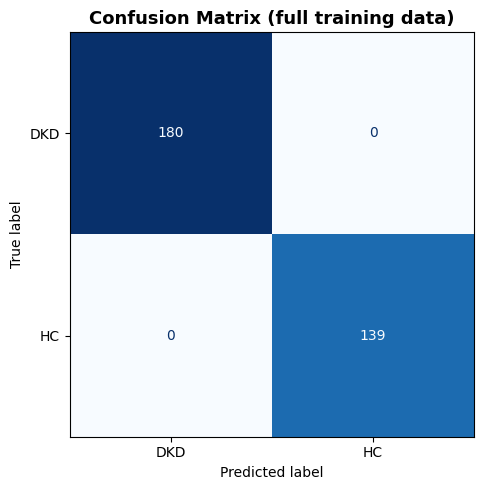


Classification Report:
              precision    recall  f1-score   support

         DKD       1.00      1.00      1.00       180
          HC       1.00      1.00      1.00       139

    accuracy                           1.00       319
   macro avg       1.00      1.00      1.00       319
weighted avg       1.00      1.00      1.00       319

✅ Saved: confusion_matrix.png


In [31]:
y_pred = model.predict(X)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels = classes,
    cmap           = "Blues",
    ax             = ax,
    colorbar       = False
)
ax.set_title("Confusion Matrix (full training data)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=classes))
print("✅ Saved: confusion_matrix.png")

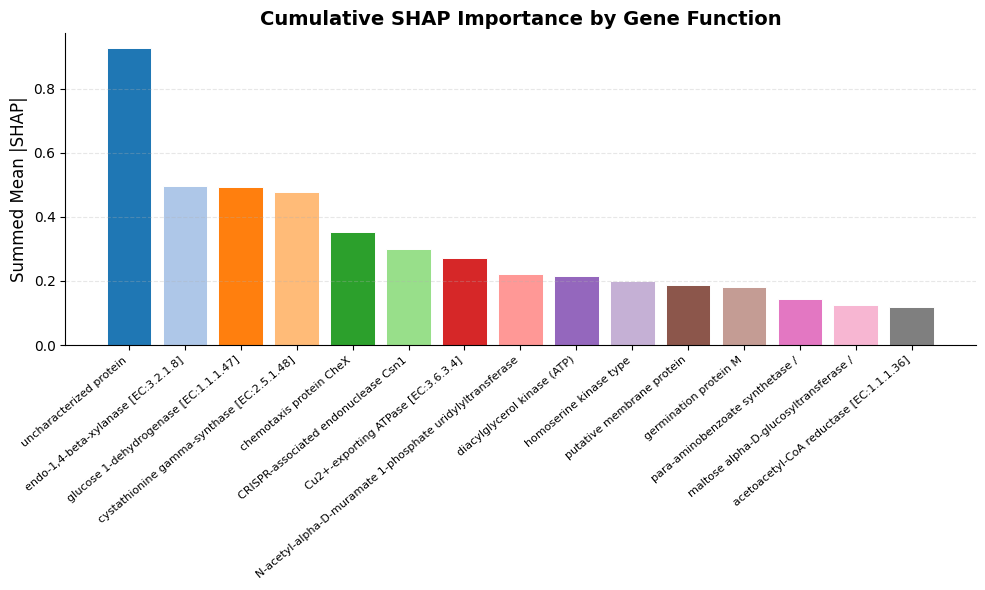

✅ Saved: gene_function_importance.png


In [32]:
shap_df["Category"] = shap_df["definition"].apply(
    lambda x: " ".join(str(x).split()[:3]) if x not in ["No annotation", "Unknown"] else "Unclassified"
)

cat_imp = (
    shap_df[shap_df["Category"] != "Unclassified"]
    .groupby("Category")["Mean_SHAP"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

if len(cat_imp) > 0:
    palette = sns.color_palette("tab20", len(cat_imp))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(cat_imp)), cat_imp["Mean_SHAP"],
           color=palette, edgecolor="white", linewidth=0.7)
    ax.set_xticks(range(len(cat_imp)))
    ax.set_xticklabels(cat_imp["Category"], rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Summed Mean |SHAP|", fontsize=12)
    ax.set_title("Cumulative SHAP Importance by Gene Function",
                 fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("gene_function_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: gene_function_importance.png")
else:
    print("⚠️  Function plot skipped — no annotations available.")

In [33]:
from google.colab import files as colab_files

importance_df.to_csv("xgboost_gene_importance.csv", index=False)
shap_df.to_csv("xgboost_shap_gene_importance.csv", index=False)
print("✅ CSVs saved")

print("\n" + "═"*55)
print("  ANALYSIS COMPLETE — SUMMARY")
print("═"*55)
print(f"  Samples analysed  : {len(X)}")
print(f"  KO genes used     : {len(feature_names)}")
print(f"  Target variable   : {TARGET_COLUMN}  ({CLASS_POSITIVE} vs {CLASS_NEGATIVE})")
print(f"  CV AUC            : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\n  Top 10 Key Genes (SHAP ranking):")
print("  " + "─"*45)
print(shap_df[["KO","gene_name","Mean_SHAP","definition"]].head(10).to_string(index=False))
print("═"*55)

print("\n📥 Downloading result files ...")
for fname in [
    "xgboost_gene_importance.csv",
    "xgboost_shap_gene_importance.csv",
    "importance_plots.png",
    "shap_beeswarm.png",
    "confusion_matrix.png",
    "gene_function_importance.png",
]:
    try:
        colab_files.download(fname)
        print(f"   ✅ {fname}")
    except Exception as e:
        print(f"   ⚠️  {fname} — {e}")

✅ CSVs saved

═══════════════════════════════════════════════════════
  ANALYSIS COMPLETE — SUMMARY
═══════════════════════════════════════════════════════
  Samples analysed  : 319
  KO genes used     : 4398
  Target variable   : Groups  (DKD vs HC)
  CV AUC            : 0.9884 ± 0.0032

  Top 10 Key Genes (SHAP ranking):
  ─────────────────────────────────────────────
    KO gene_name  Mean_SHAP                                                              definition
K01181  E3.2.1.8   0.496669                                     endo-1,4-beta-xylanase [EC:3.2.1.8]
K00034       gdh   0.493372                                   glucose 1-dehydrogenase [EC:1.1.1.47]
K01739      metB   0.478073                              cystathionine gamma-synthase [EC:2.5.1.48]
K07080    K07080   0.448492                                                 uncharacterized protein
K03409      cheX   0.353858                                                 chemotaxis protein CheX
K09952      csn1   0.298929

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ xgboost_gene_importance.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ gene_function_importance.png
